# Parkinsons Disease

#### Problem Statement

This dataset is composed of a range of biomedical voice measurements from 
31 people, 23 with Parkinson's disease (PD). Each column in the table is a 
particular voice measure, and each row corresponds one of 195 voice 
recording from these individuals ("name" column). 

The main aim of the data 
is to discriminate healthy people from those with PD, according to "status" 
column which is set to 0 for healthy and 1 for PD.

#### Data Set Information

Attribute Information:

Matrix column entries (attributes):

name - ASCII subject name and recording number

MDVP:Fo(Hz) - Average vocal fundamental frequency

MDVP:Fhi(Hz) - Maximum vocal fundamental frequency

MDVP:Flo(Hz) - Minimum vocal fundamental frequency

MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP - Several 
measures of variation in fundamental frequency

MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA - Several measures of variation in amplitude

NHR,HNR - Two measures of ratio of noise to tonal components in the voice

status - Health status of the subject (one) - Parkinson's, (zero) - healthy

RPDE,D2 - Two nonlinear dynamical complexity measures

DFA - Signal fractal scaling exponent

spread1,spread2,PPE - Three nonlinear measures of fundamental frequency variation 

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import roc_curve,auc,roc_auc_score

from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
#from sklearn.ensemble import StackingClassifier


import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import files 
  
  
uploaded = files.upload()

Saving parkinsons_data.csv to parkinsons_data.csv


In [4]:
import io 
  
DF = pd.read_csv(io.BytesIO(uploaded['parkinsons_data.csv'])) 

In [5]:
DF.shape

(195, 24)

- The dataset contains 24 columns and 195 rows

- We see that the data set is pretty small.

In [6]:
DF.head(5).T

,0,1,2,3,4
name,phon_R01_S01_1,phon_R01_S01_2,phon_R01_S01_3,phon_R01_S01_4,phon_R01_S01_5
MDVP:Fo(Hz),119.992,122.4,116.682,116.676,116.014
MDVP:Fhi(Hz),157.302,148.65,131.111,137.871,141.781
MDVP:Flo(Hz),74.997,113.819,111.555,111.366,110.655
MDVP:Jitter(%),0.00784,0.00968,0.0105,0.00997,0.01284
MDVP:Jitter(Abs),7e-05,8e-05,9e-05,9e-05,0.00011
MDVP:RAP,0.0037,0.00465,0.00544,0.00502,0.00655
MDVP:PPQ,0.00554,0.00696,0.00781,0.00698,0.00908
Jitter:DDP,0.01109,0.01394,0.01633,0.01505,0.01966
MDVP:Shimmer,0.04374,0.06134,0.05233,0.05492,0.06425


- The first column is "name" column which is name given to each of the recording and nothing to do with the model attriibutes. So, we can drop it.
- We can also see that the "status" column is  binary variable.
- Various characters [ :,(,),% ] are part of the column names. I will be replacing all those characters in columns names with suitable names.
- Also, we can see that the target column is present in the middle. So, it is best to drop it and append it at the end.


In [7]:
DF.rename(columns={"MDVP:Fo(Hz)":"MDVP_Fo_Hz","MDVP:Fhi(Hz)":"MDVP_Fhi_Hz","MDVP:Flo(Hz)":"MDVP_Flo_Hz", "MDVP:Jitter(%)":"MDVP_Jitter_pct","MDVP:Jitter(Abs)":"MDVP_Jitter_Abs","MDVP:RAP":"MDVP_RAP", "MDVP:PPQ":"MDVP_PPQ", "Jitter:DDP":"Jitter_DDP","MDVP:Shimmer":"MDVP_Shimmer","MDVP:Shimmer(dB)":"MDVP_Shimmer_dB","Shimmer:APQ3":"Shimmer_APQ3","Shimmer:APQ5":"Shimmer_APQ5","MDVP:APQ":"MDVP_APQ","Shimmer:DDA":"Shimmer_DDA"}, inplace = True) 

###### Shifting the status column to the end

In [8]:
status= DF['status']
DF.drop(['status'], axis = 1,inplace = True)
DF['status'] = status
DF.head()

,name,MDVP_Fo_Hz,MDVP_Fhi_Hz,MDVP_Flo_Hz,MDVP_Jitter_pct,MDVP_Jitter_Abs,MDVP_RAP,MDVP_PPQ,Jitter_DDP,MDVP_Shimmer,MDVP_Shimmer_dB,Shimmer_APQ3,Shimmer_APQ5,MDVP_APQ,Shimmer_DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,0.02182,0.03130,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,1
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,1
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,0.02757,0.03858,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,1
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,0.02924,0.04005,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,1
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,0.03490,0.04825,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,1


- The target column, status , is appended at the end.

##### Data types of various columns in the dataset

In [9]:
DF.dtypes

name                object
MDVP_Fo_Hz         float64
MDVP_Fhi_Hz        float64
MDVP_Flo_Hz        float64
MDVP_Jitter_pct    float64
MDVP_Jitter_Abs    float64
MDVP_RAP           float64
MDVP_PPQ           float64
Jitter_DDP         float64
MDVP_Shimmer       float64
MDVP_Shimmer_dB    float64
Shimmer_APQ3       float64
Shimmer_APQ5       float64
MDVP_APQ           float64
Shimmer_DDA        float64
NHR                float64
HNR                float64
RPDE               float64
DFA                float64
spread1            float64
spread2            float64
D2                 float64
PPE                float64
status               int64
dtype: object

In [10]:
DF.dtypes.value_counts()


float64    22
object      1
int64       1
dtype: int64

- Name column is of data type, object. 
- Status column is of data type, int.
- Rest all columns are of data type, float.

#### Checking for null values

In [11]:
DF.isnull().sum()

name               0
MDVP_Fo_Hz         0
MDVP_Fhi_Hz        0
MDVP_Flo_Hz        0
MDVP_Jitter_pct    0
MDVP_Jitter_Abs    0
MDVP_RAP           0
MDVP_PPQ           0
Jitter_DDP         0
MDVP_Shimmer       0
MDVP_Shimmer_dB    0
Shimmer_APQ3       0
Shimmer_APQ5       0
MDVP_APQ           0
Shimmer_DDA        0
NHR                0
HNR                0
RPDE               0
DFA                0
spread1            0
spread2            0
D2                 0
PPE                0
status             0
dtype: int64

- This shows that all the columns in the dataset do not have any null values.
- There are no null values present in the dataset

In [12]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             195 non-null    object 
 1   MDVP_Fo_Hz       195 non-null    float64
 2   MDVP_Fhi_Hz      195 non-null    float64
 3   MDVP_Flo_Hz      195 non-null    float64
 4   MDVP_Jitter_pct  195 non-null    float64
 5   MDVP_Jitter_Abs  195 non-null    float64
 6   MDVP_RAP         195 non-null    float64
 7   MDVP_PPQ         195 non-null    float64
 8   Jitter_DDP       195 non-null    float64
 9   MDVP_Shimmer     195 non-null    float64
 10  MDVP_Shimmer_dB  195 non-null    float64
 11  Shimmer_APQ3     195 non-null    float64
 12  Shimmer_APQ5     195 non-null    float64
 13  MDVP_APQ         195 non-null    float64
 14  Shimmer_DDA      195 non-null    float64
 15  NHR              195 non-null    float64
 16  HNR              195 non-null    float64
 17  RPDE            

##### Summary statistics

In [13]:
DF.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MDVP_Fo_Hz,195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP_Fhi_Hz,195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP_Flo_Hz,195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP_Jitter_pct,195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP_Jitter_Abs,195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP_RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP_PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter_DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP_Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP_Shimmer_dB,195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


- We can see that these columns, MDVP_Fo_Hz, MDVP_Fhi_Hz, MDVP_Flo_Hz, have high values when compared to the other columns.

- Status column has only two values , 0 and 1.

- Rest all columns, have values almost equal to zero.

- These columns, MDVP_Fo_Hz, MDVP_Fhi_Hz, MDVP_Flo_Hz, are measured in Hertz.

- This column, MDVP_Shimmer_dB, is measured in decibels.

- This column, MDVP_Jitter_pct, is measured in percentage.

- As the independent variables are measured in different scales, we need to scale or normalise them so that all the values will lie in the same range. 


In [14]:
DF.describe(include="object")


,name
count,195
unique,195
top,phon_R01_S49_6
freq,1


##### Checking for duplicates records in the data

In [15]:
DF.duplicated().sum()

0

- No duplicate records are present in the dataset

##### Distribution of target column

In [16]:
DF['status'].value_counts()


1    147
0     48
Name: status, dtype: int64

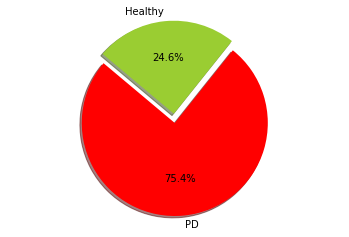

In [17]:
labels ='PD',  'Healthy'
data= DF['status'].value_counts()
colors = ['red', 'yellowgreen']
explode = (0.1, 0) 
plt.pie(data, explode=explode, labels=labels, colors=colors,autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')
plt.show()

- Out of the 195 voice recordings, 75.4% of the recording belong to people who have PD. 
- Only 24.6% of the voice recordings belong to people who are healthy.
- We can that the data is imbalanced.

In [18]:
DF.columns

Index(['name', 'MDVP_Fo_Hz', 'MDVP_Fhi_Hz', 'MDVP_Flo_Hz', 'MDVP_Jitter_pct',
       'MDVP_Jitter_Abs', 'MDVP_RAP', 'MDVP_PPQ', 'Jitter_DDP', 'MDVP_Shimmer',
       'MDVP_Shimmer_dB', 'Shimmer_APQ3', 'Shimmer_APQ5', 'MDVP_APQ',
       'Shimmer_DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2',
       'PPE', 'status'],
      dtype='object')

## Distribution of various columns

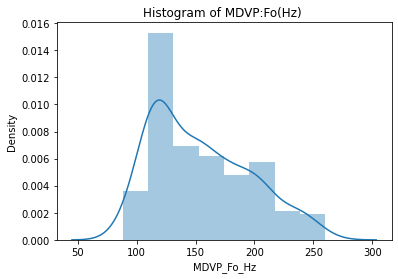

In [19]:
sns.distplot(DF['MDVP_Fo_Hz'])
plt.title('Histogram of MDVP:Fo(Hz) ')
plt.show();

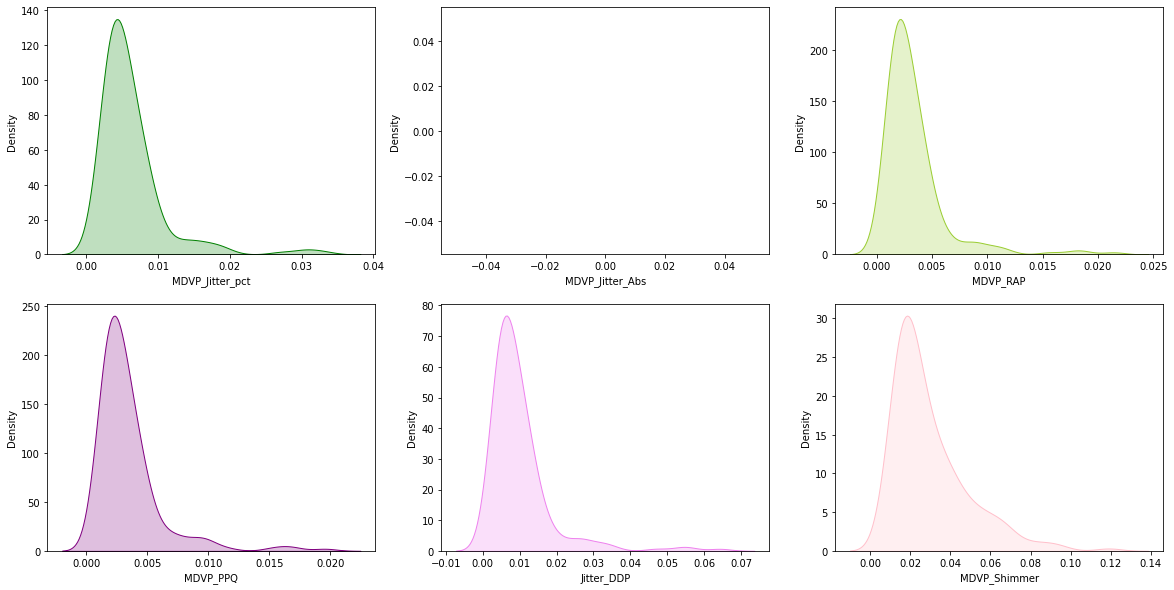

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
sns.kdeplot(DF['MDVP_Jitter_pct'], color="green", shade = True, ax=axes[0,0])
sns.kdeplot(DF['MDVP_Jitter_Abs'], color="seagreen", shade = True, ax=axes[0,1])
sns.kdeplot(DF['MDVP_RAP'], color="yellowgreen", shade = True, ax=axes[0,2])
sns.kdeplot(DF['MDVP_PPQ'], color="purple", shade = True, ax=axes[1,0])
sns.kdeplot(DF['Jitter_DDP'], color="violet", shade = True, ax=axes[1,1])
sns.kdeplot(DF['MDVP_Shimmer'], color="pink", shade = True, ax=axes[1,2])



- All of these columns have longer right tails.

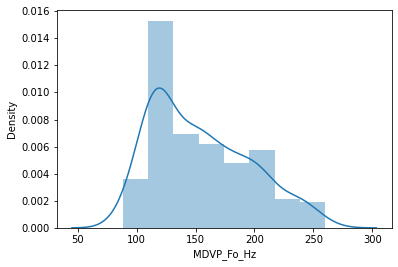

In [21]:
sns.distplot(DF['MDVP_Fo_Hz'])


- MDVP_Fo_Hz looks normally distributed.

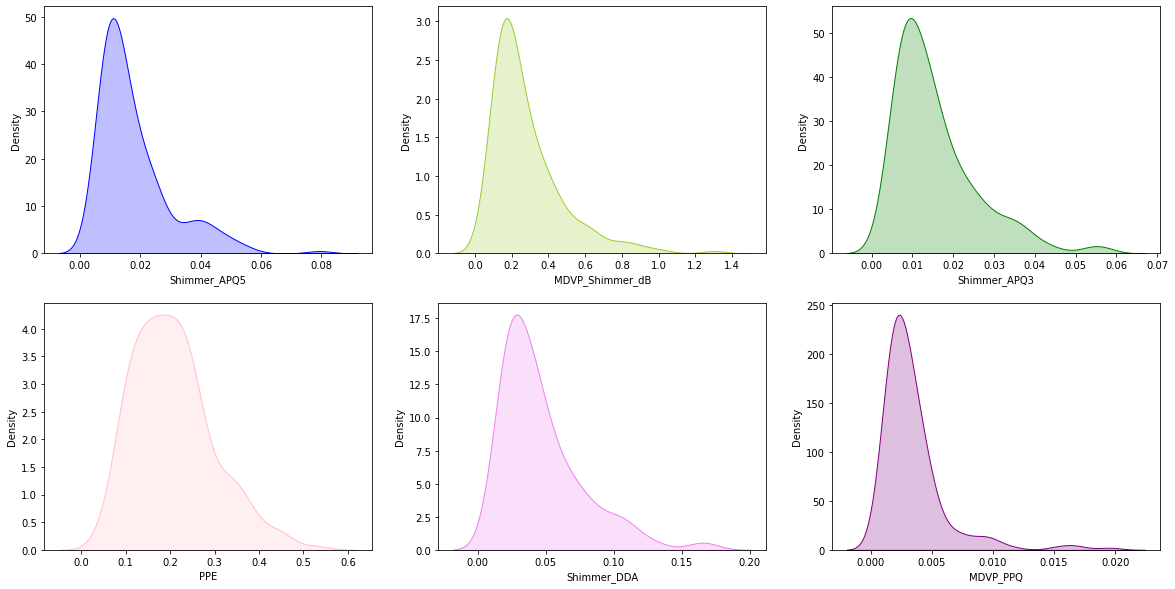

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
sns.kdeplot(DF['Shimmer_APQ5'], color="blue", shade = True, ax=axes[0,0])
sns.kdeplot(DF['MDVP_Shimmer_dB'], color="yellowgreen", shade = True, ax=axes[0,1])
sns.kdeplot(DF['Shimmer_APQ3'], color="green", shade = True, ax=axes[0,2])
sns.kdeplot(DF['PPE'], color="pink", shade = True, ax=axes[1,0])
sns.kdeplot(DF['Shimmer_DDA'], color="violet", shade = True, ax=axes[1,1])
sns.kdeplot(DF['MDVP_PPQ'], color="purple", shade = True, ax=axes[1,2])





- For these columns ,Shimmer_APQ5, MDVP_Shimmer_dB, Shimmer_APQ3, Shimmer_DDA, MDVP_APQ, the right tail is longer.

- PPE columns looks like normally distributed.


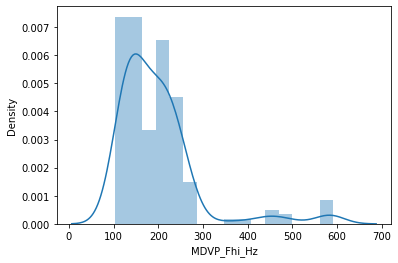

In [23]:
sns.distplot(DF['MDVP_Fhi_Hz'])


- We can see that the tail is longer near the right hand side of the distribution. Also, we can see two peaks for this column.

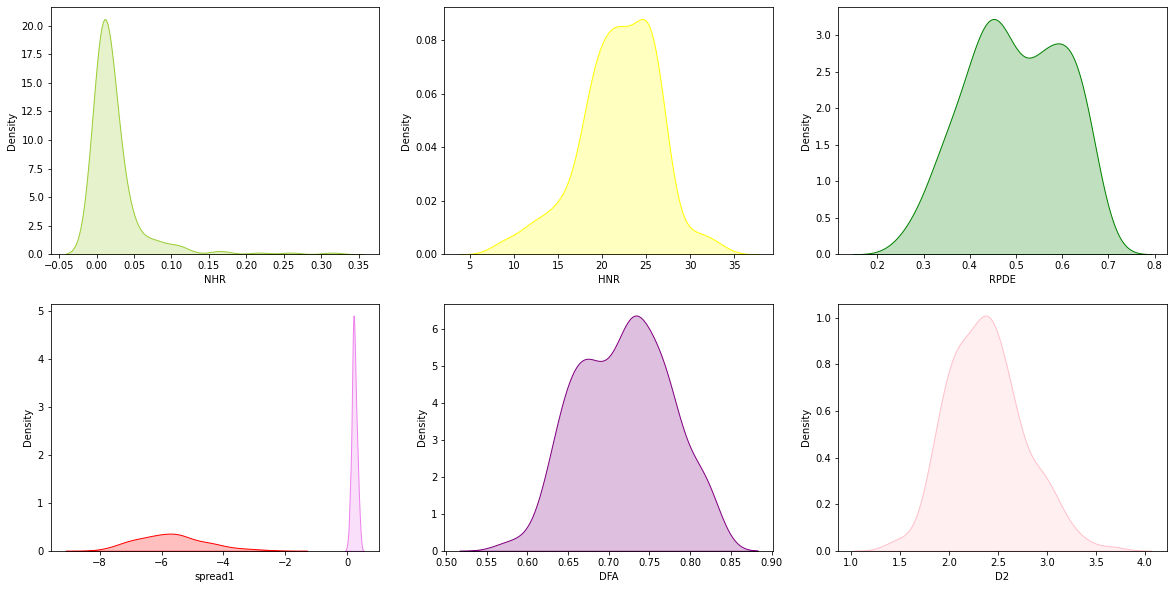

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
sns.kdeplot(DF['NHR'], color="yellowgreen", shade = True, ax=axes[0,0])
sns.kdeplot(DF['HNR'], color="yellow", shade = True, ax=axes[0,1])
sns.kdeplot(DF['RPDE'], color="green", shade = True, ax=axes[0,2])
sns.kdeplot(DF['spread1'], color="red", shade = True, ax=axes[1,0])
sns.kdeplot(DF['spread2'], color="violet", shade = True, ax=axes[1,0])
sns.kdeplot(DF['DFA'], color="purple", shade = True, ax=axes[1,1])
sns.kdeplot(DF['D2'], color="pink", shade = True, ax=axes[1,2])

- NHR column has long right tail.

- RPDE, DFA have two peaks.

- HNR and D2 are almost normally distributed.

- Spread 1 and spread 2 are also normally distributed. Also, the peak of spread 2 is less than the peak of spread 1.

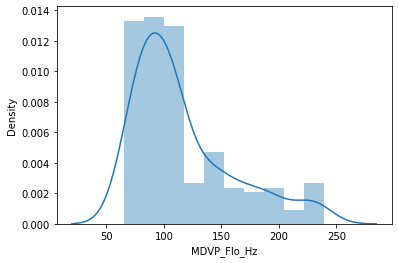

In [25]:
sns.distplot(DF['MDVP_Flo_Hz'])


- we can see that the tail is longer near the right hand side of the distribution

## BOXPLOT

In [26]:
df= DF.drop('name', axis=1)


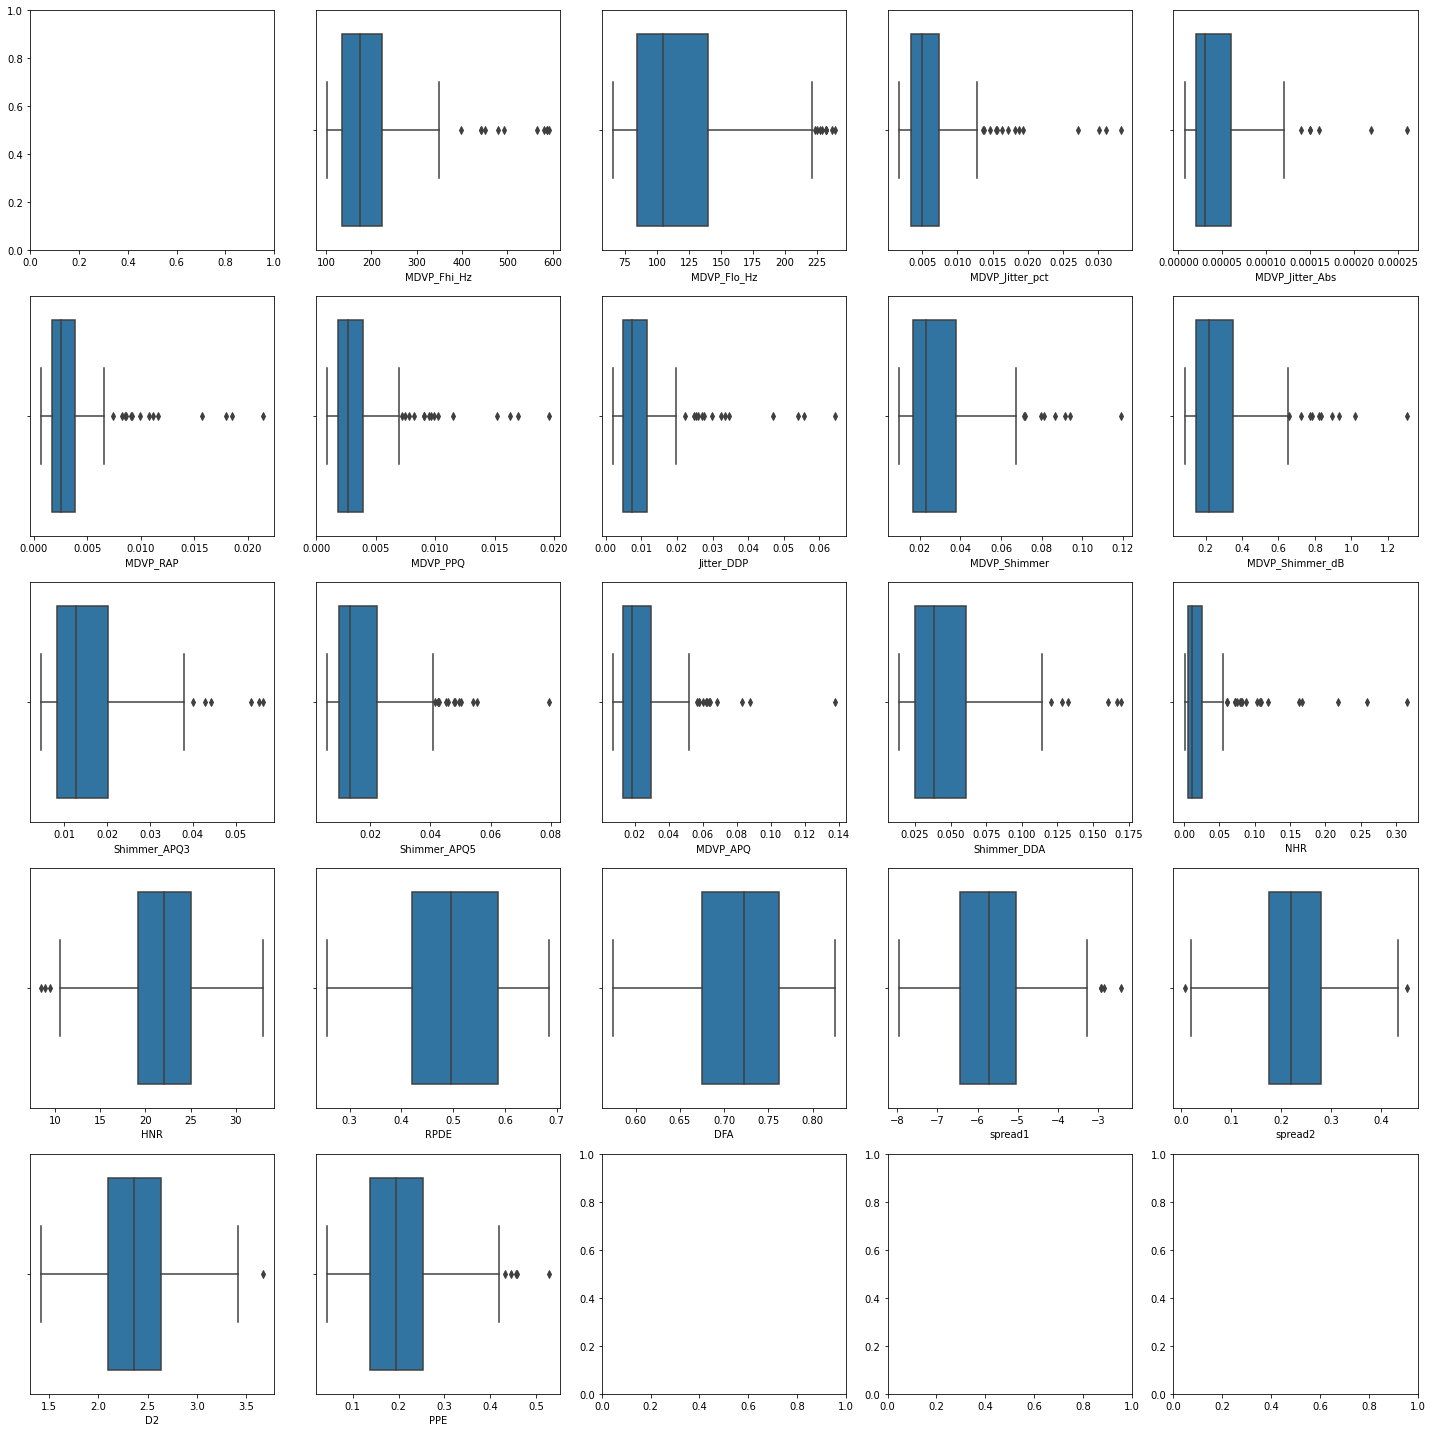

In [27]:
fig,axes=plt.subplots(5,5,figsize=(20,20))
axes=axes.flatten()

for i in range(1,len(df.columns)-1):
    sns.boxplot(df.iloc[:,i],data=df,orient='v',ax=axes[i])
plt.tight_layout()
plt.show()

- Most of the columns have outliers in them.

- RPDE, DFA, MDVP_Fo_Hz have no outliers in them.

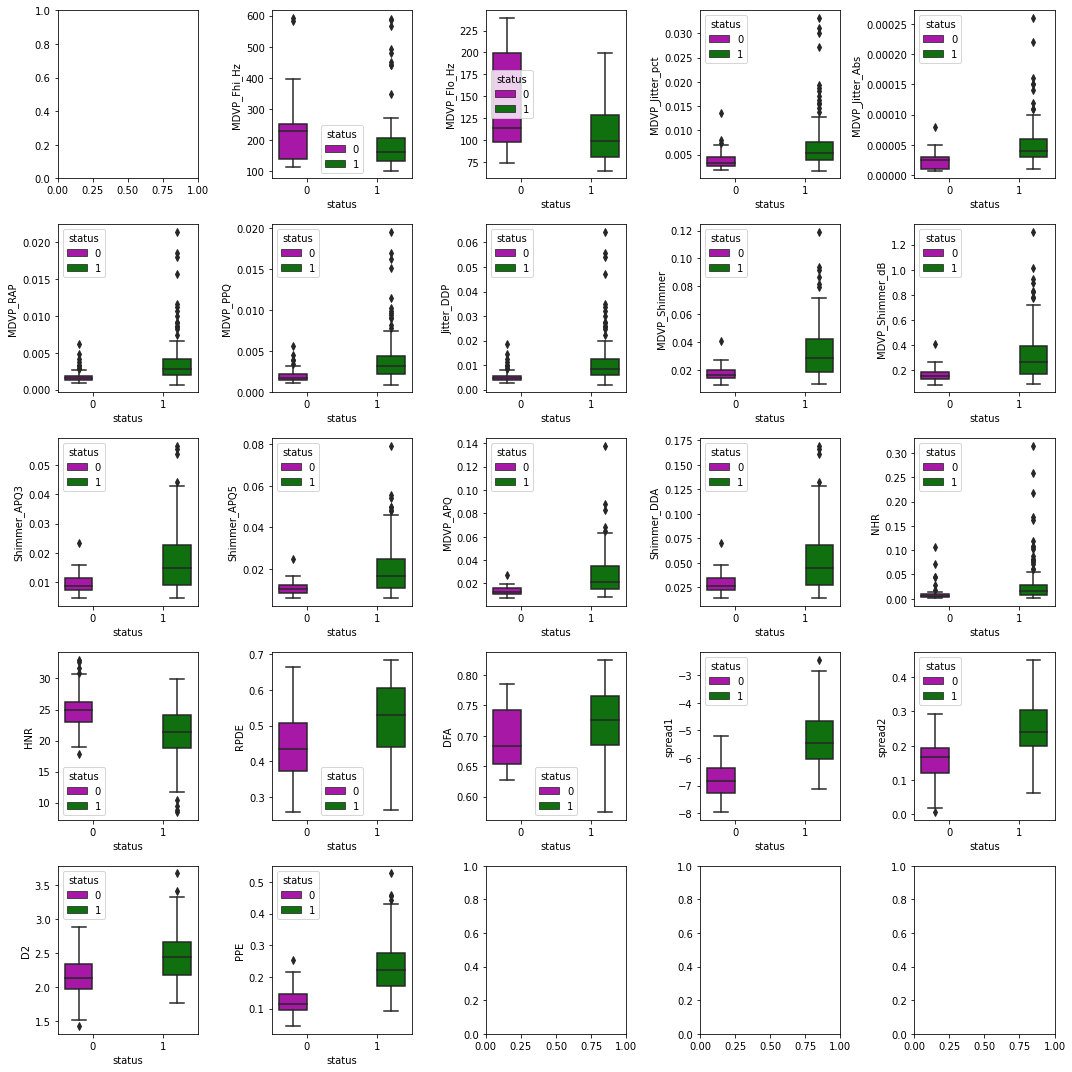

In [28]:
fig,axes=plt.subplots(5,5,figsize=(15,15))
axes=axes.flatten()

for i in range(1,len(df.columns)-1):
    sns.boxplot(x=df['status'], y=df.iloc[:,i],data=df,orient='v',ax=axes[i], hue="status", palette=["m", "g"])
plt.tight_layout()
plt.show()

- From the above plot, we can see the distribution of outliers in each column seperately for people with Parkinson's Disease and healthy people.

## Pairplot

In [29]:
PD_pairplot= sns.pairplot(DF, hue='status',height =10, aspect=0.6)
PD_pairplot.fig.set_size_inches(30,30)

Output hidden; open in https://colab.research.google.com to view.

- NHR for person with Parkinson's Disease is higher than that of the healthy person.

- Jitter Abs value is almost same for for healthy and Positive patients.

- "Jitter_DDP" and "MDVP_RAP" have strong positive correlation.

- "Jitter_DDP" has strong positive correlation with MDVP_PPQ, MDVP:Jitter_Abs, MDVP_Jitter_pct columns as well.

- "Shimmer-APQ3" and "Shimmer-DDA" have strong positive correlation.

- MDVP_Fhi_Hz of people affected with Parkinson's Disease and healthy people have a strong overlap with each other.

- MDVP:Shimmer has a strong corellation with MDVP:Shimmer(dB), Shimmer:APQ3, Shimmer:APQ5, and Shimmer:DDA.

- Also, we see that for most of the independent variables, the kde plot is overlapping. We don't have any clear seperation between people affected with Parkinson's disease and healthy people.

## Heatmap

(23.5, -0.5)

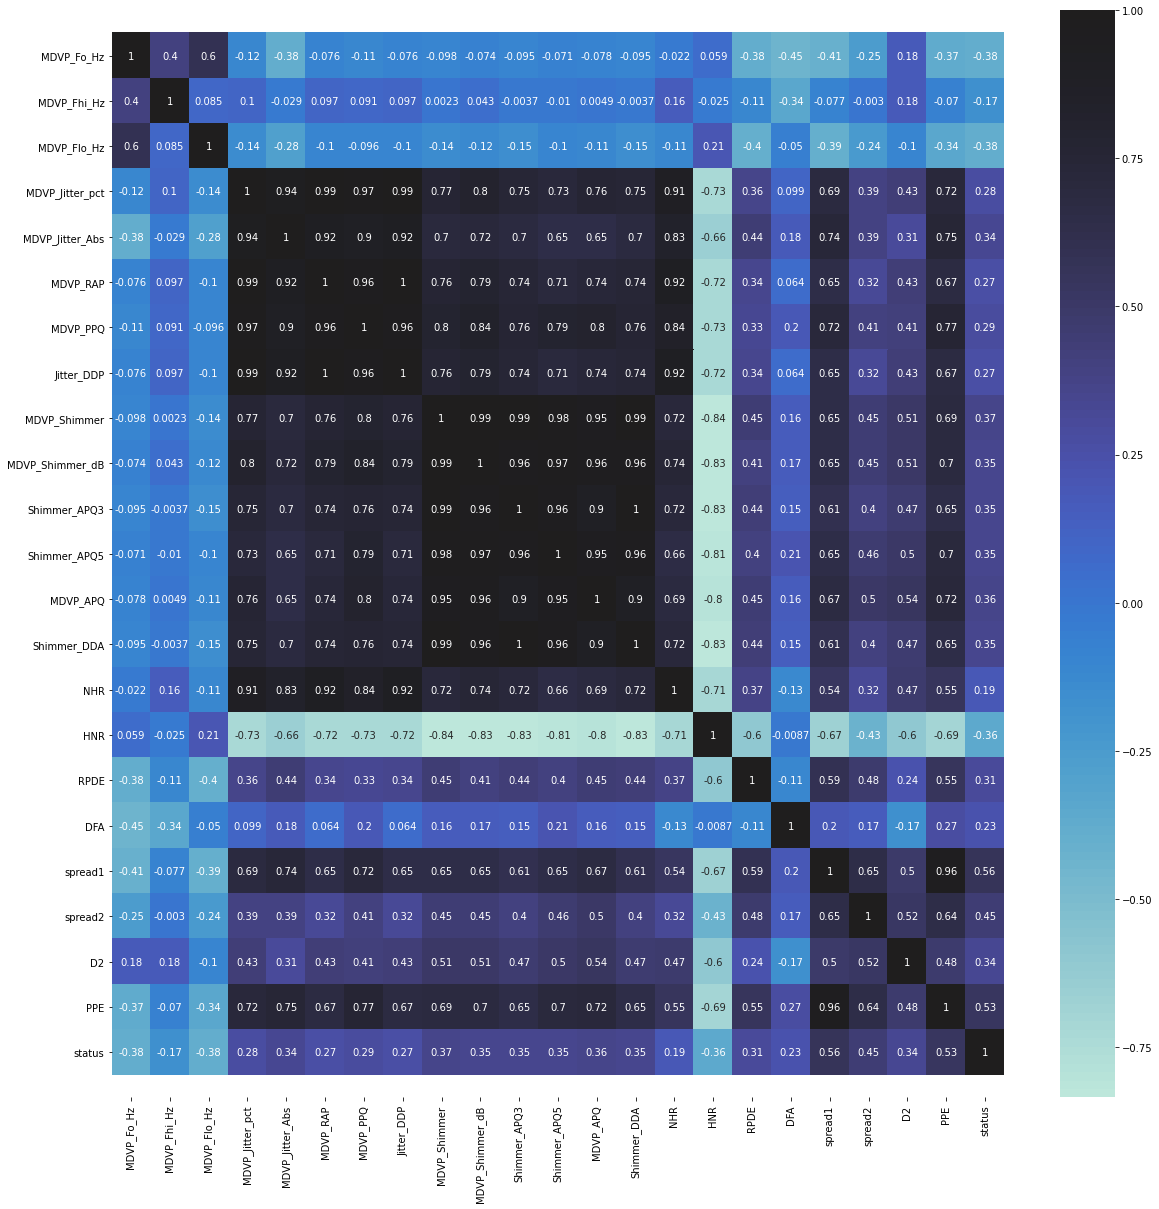

In [30]:
fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(DF.corr(), annot=True, center=1) 
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)


- MDVP_RAP and Jitter_DDP have strong correlation of 0.99 with MDVP_Jitter_pct.

- MDVP_PPQ has a correlation of 0.97 with MDVP_Jitter_pct. MDVP_Jitter_Abs has a correlation of 0.94 with MDVP_Jitter_pct.

- NHR has a correlation of 0.91 with MDVP_Jitter_pct.

- 'MDVP_Shimmer_dB', 'Shimmer_APQ3', 'Shimmer_APQ5', 'MDVP_APQ','Shimmer_DDA' have strong positive correlation with 'MDVP_Shimmer'

- Jitter_DDP, MDVP_RAP have strong correlation with NHR.


In [31]:
DF.columns

Index(['name', 'MDVP_Fo_Hz', 'MDVP_Fhi_Hz', 'MDVP_Flo_Hz', 'MDVP_Jitter_pct',
       'MDVP_Jitter_Abs', 'MDVP_RAP', 'MDVP_PPQ', 'Jitter_DDP', 'MDVP_Shimmer',
       'MDVP_Shimmer_dB', 'Shimmer_APQ3', 'Shimmer_APQ5', 'MDVP_APQ',
       'Shimmer_DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2',
       'PPE', 'status'],
      dtype='object')

### Skewness


In [57]:
DF.skew(numeric_only= True)

MDVP_Fo_Hz         0.591737
MDVP_Fhi_Hz        2.542146
MDVP_Flo_Hz        1.217350
MDVP_Jitter_pct    3.084946
MDVP_Jitter_Abs    2.649071
MDVP_RAP           3.360708
MDVP_PPQ           3.073892
Jitter_DDP         3.362058
MDVP_Shimmer       1.666480
MDVP_Shimmer_dB    1.999389
Shimmer_APQ3       1.580576
Shimmer_APQ5       1.798697
MDVP_APQ           2.618047
Shimmer_DDA        1.580618
NHR                4.220709
HNR               -0.514317
RPDE              -0.143402
DFA               -0.033214
spread1            0.432139
spread2            0.144430
D2                 0.430384
PPE                0.797491
status            -1.187727
dtype: float64

**Positive Skew** - denotes right tail is longer

**Negative Skew** - denotes left tail is longer

Symmetrical distribution: 

- Values close to 0

- MDVP:Fo(Hz), spread1, spread2, PPE, D2, RPDE, DFA

Negative skewness:
- Tail is larger towards the left hand side of the distribution

- HNR column has negative skewness.


Positive skewness:
- Tail is larger towards the Right hand side of the distribution 

- All other attributes have a very high distribution towards right of the median



### Kurtosis

In [58]:
DF.kurtosis(numeric_only= True)

MDVP_Fo_Hz         -0.627898
MDVP_Fhi_Hz         7.627241
MDVP_Flo_Hz         0.654615
MDVP_Jitter_pct    12.030939
MDVP_Jitter_Abs    10.869043
MDVP_RAP           14.213798
MDVP_PPQ           11.963922
Jitter_DDP         14.224762
MDVP_Shimmer        3.238308
MDVP_Shimmer_dB     5.128193
Shimmer_APQ3        2.720152
Shimmer_APQ5        3.874210
MDVP_APQ           11.163288
Shimmer_DDA         2.720661
NHR                21.994974
HNR                 0.616036
RPDE               -0.921781
DFA                -0.686152
spread1            -0.050199
spread2            -0.083023
D2                  0.220334
PPE                 0.528335
status             -0.595518
dtype: float64

- The below columns have high positive value of kurtosis, which implies that more data is distributed around the tails

**MDVP_Fhi_Hz, MDVP_Jitter_pct, MDVP_Jitter_Abs, MDVP_RAP, MDVP_PPQ, Jitter_DDP, MDVP_Shimmer, MDVP_Shimmer_dB, Shimmer_APQ3, Shimmer_APQ5, MDVP_APQ, Shimmer_DDA, NHR**

- RPDE , DFA, status, MDVP_Fo_Hz columns have negative kurtosis.

- For the rest of the columns the kurtosis is close to 0.

### Hypothesis Testing

In [59]:
import scipy.stats as stats

Healthy_NHR=np.array(DF[DF['status']==1].NHR)
PD_NHR=np.array(DF[DF['status']==0].NHR)

t,p_value=stats.ttest_ind(Healthy_NHR,PD_NHR,axis=0)

p_value

0.007994850518899727

In [60]:
# p value is less than level of significance ,0.05. So, NHR does have significant impact on diagnosis

In [61]:
Healthy_MDVP_Shimmer_dB=np.array(DF[DF['status']==1].MDVP_Shimmer_dB)
PD_MDVP_Shimmer_dB=np.array(DF[DF['status']==0].MDVP_Shimmer_dB)

t,p_value=stats.ttest_ind(Healthy_MDVP_Shimmer_dB,PD_MDVP_Shimmer_dB,axis=0)

p_value

5.000743178590637e-07

In [62]:
# p value is less than level of significance ,0.05. So, MDVP:Shimmer(dB) does have significant impact on diagnosis

In [63]:
Healthy_HNR=np.array(DF[DF['status']==1].HNR)
PD_HNR=np.array(DF[DF['status']==0].HNR)

t,p_value=stats.ttest_ind(Healthy_HNR,PD_HNR,axis=0)

p_value

2.0746773596797e-07

In [64]:
# p value is less than level of significance ,0.05. So, HNR does have significant impact on diagnosis

In [65]:
Healthy_MDVP_Jitter_Abs=np.array(DF[DF['status']==1].MDVP_Jitter_Abs)
PD_MDVP_Jitter_Abs=np.array(DF[DF['status']==0].MDVP_Jitter_Abs)

t,p_value=stats.ttest_ind(Healthy_MDVP_Jitter_Abs,PD_MDVP_Jitter_Abs,axis=0)

p_value

1.2822523240682423e-06

In [66]:
# p value is less than level of significance ,0.05. So, MDVP:Jitter(Abs) does have significant impact on diagnosis

In [67]:
Healthy_spread1=np.array(DF[DF['status']==1].spread1)
PD_spread1=np.array(DF[DF['status']==0].spread1)

t,p_value=stats.ttest_ind(Healthy_spread1,PD_spread1,axis=0)

p_value

7.909650873104307e-18

In [68]:
# p value is less than level of significance ,0.05. So, spread1 does have significant impact on diagnosis

In [69]:
Healthy_MDVP_Fo_Hz=np.array(DF[DF['status']==1].MDVP_Fo_Hz)
PD_MDVP_Fo_Hz=np.array(DF[DF['status']==0].MDVP_Fo_Hz)

t,p_value=stats.ttest_ind(Healthy_MDVP_Fo_Hz,PD_MDVP_Fo_Hz,axis=0)

p_value

3.121919402836372e-08

In [70]:
# p value is less than level of significance ,0.05. So, MDVP:Fo(Hz) does have significant impact on diagnosis

### VIF

In [71]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
df=DF.copy()

In [72]:
df=df.drop('name', axis=1)
def calc_vif(df):
    vif = pd.DataFrame()
    vif["variables"] = df.columns
    vif["VIF"] = ['{0:1.3f}'.format(variance_inflation_factor(df.values, i)) for i in range(df.shape[1])]
    return(vif)

In [73]:
df = df.iloc[:,:-1]

In [74]:
calc_vif(df)

,variables,VIF
0,MDVP_Fo_Hz,102.243
1,MDVP_Fhi_Hz,8.880
2,MDVP_Flo_Hz,18.052
3,MDVP_Jitter_pct,506.561
4,MDVP_Jitter_Abs,122.717
5,MDVP_RAP,3101964.447
6,MDVP_PPQ,273.804
7,Jitter_DDP,3103948.971
8,MDVP_Shimmer,2653.657
9,MDVP_Shimmer_dB,303.102


- Shimmer_DDA,Shimmer_APQ3,Jitter_DDP, MDVP_RAP, MDVP_Shimmer have high VIF.
- It means that they can be predicted by other independent variables in the dataset.

### Data Preparation

In [75]:
# Dropping the name column as it not much useful in our analysis.

DF_Final = DF.drop(['name'], axis=1)


In [76]:
DF_Final.shape

(195, 23)

In [77]:
DF_Final.head(10)

,MDVP_Fo_Hz,MDVP_Fhi_Hz,MDVP_Flo_Hz,MDVP_Jitter_pct,MDVP_Jitter_Abs,MDVP_RAP,MDVP_PPQ,Jitter_DDP,MDVP_Shimmer,MDVP_Shimmer_dB,Shimmer_APQ3,Shimmer_APQ5,MDVP_APQ,Shimmer_DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,0.02182,0.03130,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,1
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,1
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,0.02757,0.03858,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,1
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,0.02924,0.04005,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,1
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,0.03490,0.04825,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,1
5,120.552,131.162,113.787,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,0.456,0.02328,0.03526,0.03243,0.06985,0.01222,21.378,0.415564,0.825069,-4.242867,0.299111,2.187560,0.357775,1
6,120.267,137.244,114.820,0.00333,0.00003,0.00155,0.00202,0.00466,0.01608,0.140,0.00779,0.00937,0.01351,0.02337,0.00607,24.886,0.596040,0.764112,-5.634322,0.257682,1.854785,0.211756,1
7,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,0.134,0.00829,0.00946,0.01256,0.02487,0.00344,26.892,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755,1
8,95.730,132.068,91.754,0.00551,0.00006,0.00293,0.00332,0.00880,0.02093,0.191,0.01073,0.01277,0.01717,0.03218,0.01070,21.812,0.615551,0.773587,-5.498678,0.327769,2.322511,0.231571,1
9,95.056,120.103,91.226,0.00532,0.00006,0.00268,0.00332,0.00803,0.02838,0.255,0.01441,0.01725,0.02444,0.04324,0.01022,21.862,0.547037,0.798463,-5.011879,0.325996,2.432792,0.271362,1


### Train Test Split

In [78]:
# Separating the independent attributes and storing them in X array
# Storing the target column into y array

y=DF_Final['status']
X = DF_Final.drop('status', axis=1)

In [79]:
from sklearn.model_selection import train_test_split

In [80]:
# Create the training and test data set in the ratio of 70:30 respectively.

testsize = 0.30 # taking 70:30 training and test set
seed = 10  # Random numbmer seeding for reapeatability of the code when using random functions to 
# generate the training and test data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=testsize, random_state=seed)

### Model Building

In [81]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

def fit_n_print(model, X_train, X_test, y_train, y_test):  # the function will take the model, and data as inputs
    model.fit(X_train, y_train)   # to fit the model with the train data
    pred = model.predict(X_test)  # to make predictions on the test set
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print("Train score: ",train_score)
    print("Test score:", test_score)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))
    print("Classification Report:")
    print(classification_report(y_test, pred))

### I. Model Building on Unscaled data

#### 1) Decision Tree

In [82]:
dt = DecisionTreeClassifier(criterion='entropy')

fit_n_print(dt, X_train, X_test, y_train, y_test)

Train score:  1.0
Test score: 0.9322033898305084
Confusion Matrix:
[[14  2]
 [ 2 41]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        16
           1       0.95      0.95      0.95        43

    accuracy                           0.93        59
   macro avg       0.91      0.91      0.91        59
weighted avg       0.93      0.93      0.93        59



- Train score:  1.0
- Test score: 0.9322033898305084




- We see that the precision and recall for class 0 is 0.88 and 0.88 respectively.

- Recall (true positives / (true positives + false negatives)) for class 1 is 0.95

In [83]:
predicted_values = dt.predict(X_test)

predicted_values

array([1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0])

In [84]:
pd.crosstab(y_test,predicted_values)


col_0,0,1
status,,
0,14,2
1,2,41


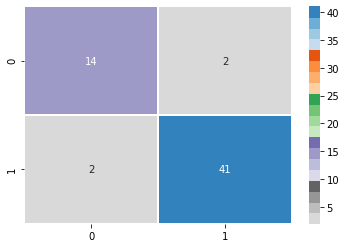

In [85]:
fig, ax = plt.subplots()


cm1_s=confusion_matrix(y_test,predicted_values,labels=[0,1])
sns.heatmap(cm1_s,annot=True,xticklabels=True,yticklabels=True,linewidths=.5,cmap='tab20c_r')




In [86]:
feature_importances = pd.DataFrame({'features': X_train.columns, 'Importance': dt.feature_importances_})
feature_importances

,features,Importance
0,MDVP_Fo_Hz,0.078002
1,MDVP_Fhi_Hz,0.087232
2,MDVP_Flo_Hz,0.000000
3,MDVP_Jitter_pct,0.000000
4,MDVP_Jitter_Abs,0.000000
5,MDVP_RAP,0.000000
6,MDVP_PPQ,0.000000
7,Jitter_DDP,0.000000
8,MDVP_Shimmer,0.000000
9,MDVP_Shimmer_dB,0.000000


- PPE is the most important feature.




- Most of the features have very less importance.

#### 2) Random Forest

In [87]:
rf = RandomForestClassifier()

fit_n_print(rf, X_train, X_test, y_train, y_test)

Train score:  1.0
Test score: 0.9491525423728814
Confusion Matrix:
[[14  2]
 [ 1 42]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        16
           1       0.95      0.98      0.97        43

    accuracy                           0.95        59
   macro avg       0.94      0.93      0.93        59
weighted avg       0.95      0.95      0.95        59



- Train score:  1.0

- Test score: 0.9491525423728814



- Precision and recall for class 1 are 0.95 and 0.98 respectively.

### II. Impact of regularisation on Decision Tree Classifier

###### 1) Varying max depth

In [88]:
N = np.arange(1, 100)
Max_depth_train_scores = np.empty(len(N))
Max_depth_test_scores = np.empty(len(N))

for i, k in enumerate(N):
    DT_Reg_max_depth = DecisionTreeClassifier(criterion = "entropy", max_depth=k)
    DT_Reg_max_depth.fit(X_train, y_train)
    train_score = DT_Reg_max_depth.score(X_train, y_train)
    test_score = DT_Reg_max_depth.score(X_test, y_test)
    Max_depth_train_scores[i]=train_score
    Max_depth_test_scores[i]=test_score

    

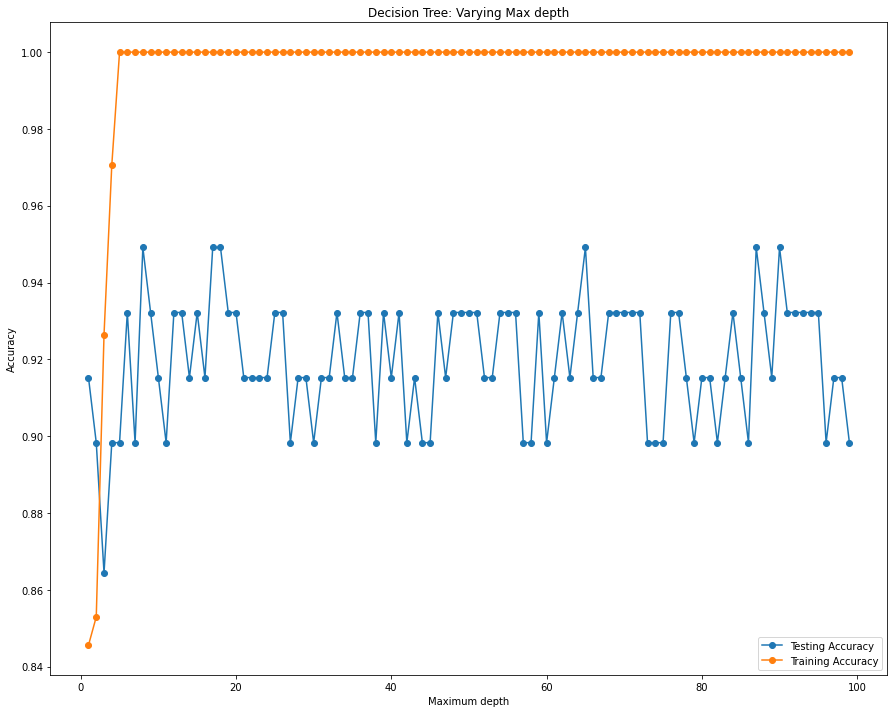

In [89]:
plt.figure(figsize=(15,12))
plt.title('Decision Tree: Varying Max depth')
plt.plot(N, Max_depth_test_scores, label = 'Testing Accuracy',  marker='o')
plt.plot(N, Max_depth_train_scores, label = 'Training Accuracy', marker='o')
plt.legend()
plt.xlabel('Maximum depth')
plt.ylabel('Accuracy')
plt.show()

- Maximum test accuracy = 0.95

- Maximum train accuracy = 1

- The training accuracy was initially less. As maximum depth is increased, the accuracy gradually increased to 1. After a certain value of maximum depth, it remained constant.  

- The testing accuracy dropped a bit initially. Then, we can see an increase in accuracy. The maximum test accuracy is close to 0.95. But, there is no fixed relationship between test accuracy and increase in maximum depth. We can see a zig zag pattern here. 

###### 2) Varying min_sample_leaf

In [90]:
N1 = np.arange(1, 100)
Max_depth_train_scores = np.empty(len(N1))
Max_depth_test_scores = np.empty(len(N1))

for i, k in enumerate(N1):
    DT_Reg_max_depth = DecisionTreeClassifier(criterion = "entropy", min_samples_leaf=k)
    DT_Reg_max_depth.fit(X_train, y_train)
    train_score = DT_Reg_max_depth.score(X_train, y_train)
    test_score = DT_Reg_max_depth.score(X_test, y_test)
    Max_depth_train_scores[i]=train_score
    Max_depth_test_scores[i]=test_score


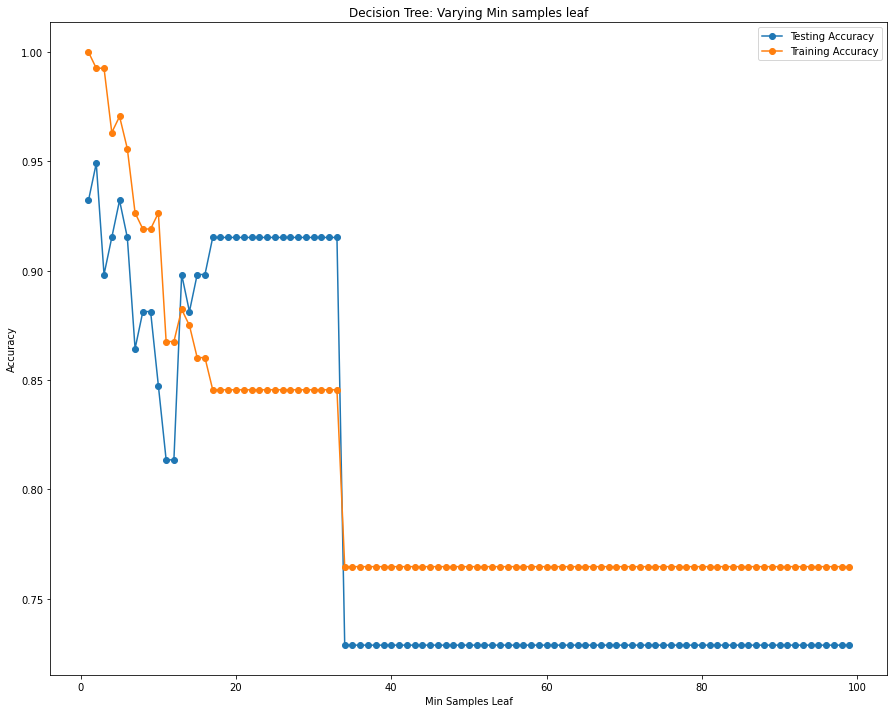

In [91]:
plt.figure(figsize=(15,12))
plt.title('Decision Tree: Varying Min samples leaf')
plt.plot(N1, Max_depth_test_scores, label = 'Testing Accuracy',  marker='o')
plt.plot(N1, Max_depth_train_scores, label = 'Training Accuracy', marker='o')
plt.legend()
plt.xlabel('Min Samples Leaf')
plt.ylabel('Accuracy')
plt.show()

- Maximum test accuracy = 0.95

- Maximum train accuracy = 1

- The training acuracy is initially close to 1. But as min samples leaf increase we can see that the dropped gradually, then remained constant and dropped again and remained constant.

- Initially, the testing accuracy is close to 0.94. As, the min samples leaf is increased upto 20, the accuracy incresed and decreased alernatingly. But when the min samples leaf approached close to 20, a steep increase of accuracy is observed(close to 0.92). After that it remained constant for some time and then as the min sample leaf crossed 30, we can see that there is a sudden decline in the accuracy(close to 0.73). It remained constant afterwards eventhough the min samples leaf is increased.

#### 3) Varying min sample split


In [92]:
N1 = np.arange(1, 100)
Min_sample_split_train_scores = np.empty(len(N1))
Min_sample_split_test_scores = np.empty(len(N1))

for i, k in enumerate(N1):
    DT_Reg_Min_sample_split = DecisionTreeClassifier(criterion = "entropy", min_samples_split=k+1)
    DT_Reg_Min_sample_split.fit(X_train, y_train)
    train_score = DT_Reg_Min_sample_split.score(X_train, y_train)
    test_score = DT_Reg_Min_sample_split.score(X_test, y_test)
    Min_sample_split_train_scores[i]=train_score
    Min_sample_split_test_scores[i]=test_score

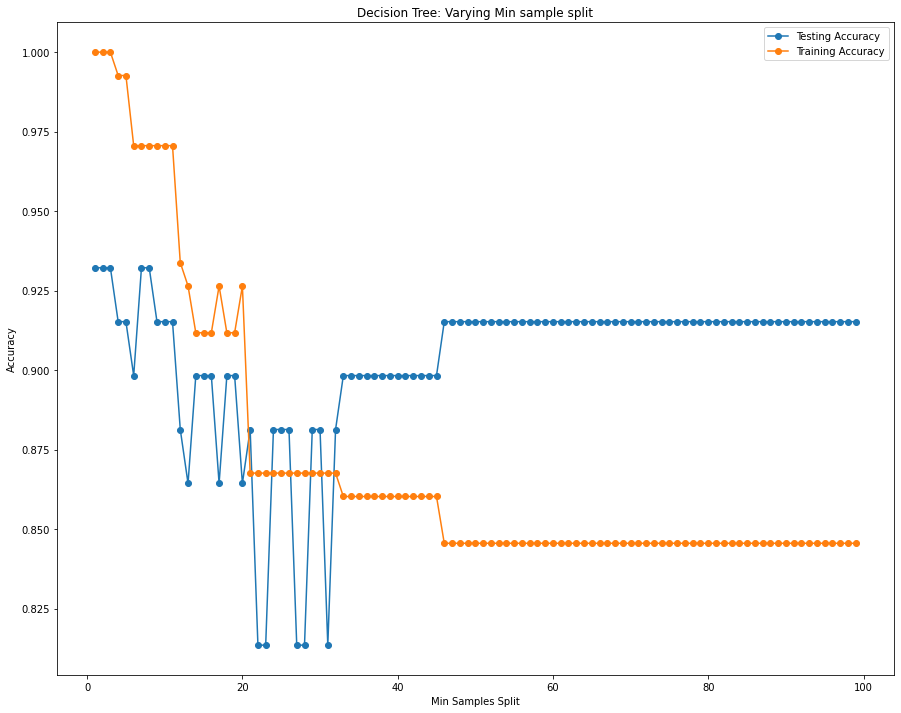

In [93]:
plt.figure(figsize=(15,12))
plt.title('Decision Tree: Varying Min sample split')
plt.plot(N1, Min_sample_split_test_scores, label = 'Testing Accuracy',  marker='o')
plt.plot(N1, Min_sample_split_train_scores, label = 'Training Accuracy', marker='o')
plt.legend()
plt.xlabel('Min Samples Split')
plt.ylabel('Accuracy')
plt.show()

- Maximum training accuracy=1 

- Maximum test accuracy = 0.95

- The training accuracy is initially 1. But as min samples split is increased, we can see that the train accuracy has reduced significantly.

- The testing accuracy is initially 0.9. As min samples split increased, we can see no fixed pattern. The test accuracy increased for some values and decreased for some.We can see that as min sample split became close to 30, we can see an increase in test accuracy. As min sample split became close to 50, the test accuracy increased to 0.92 and then remained constant. 

#### 4) Varying class weight

In [94]:
dt_model = DecisionTreeClassifier(criterion = 'entropy', class_weight={0:.05,1:.05}, max_depth = 5, min_samples_leaf=5)
fit_n_print(dt_model, X_train, X_test, y_train, y_test)

Train score:  0.9632352941176471
Test score: 0.9152542372881356
Confusion Matrix:
[[12  4]
 [ 1 42]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83        16
           1       0.91      0.98      0.94        43

    accuracy                           0.92        59
   macro avg       0.92      0.86      0.89        59
weighted avg       0.92      0.92      0.91        59



- Relatively less overfit as training accuracy is 0.96 and test accuracy is 0.91

### III. Model Building on Scaled data 

In [ ]:
## Using standard scaler to scale the data

In [95]:
sc=StandardScaler()

In [ ]:
# Splitting the data into train and test and then scaling the data

In [96]:
X_train, X_test, y1_train, y1_test = train_test_split(X, y, test_size=0.30, random_state=10)

scaledX_train = sc.fit_transform(X_train)
scaledX_test = sc.transform(X_test)

In [97]:
DT_s = DecisionTreeClassifier()

RF_s = RandomForestClassifier()


##### 1) Decision Tree

In [98]:
fit_n_print(DT_s, scaledX_train, scaledX_test, y1_train, y1_test)

Train score:  1.0
Test score: 0.8813559322033898
Confusion Matrix:
[[11  5]
 [ 2 41]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.69      0.76        16
           1       0.89      0.95      0.92        43

    accuracy                           0.88        59
   macro avg       0.87      0.82      0.84        59
weighted avg       0.88      0.88      0.88        59



##### 2) Random Forest

In [99]:
fit_n_print(RF_s, scaledX_train, scaledX_test, y_train, y_test)

Train score:  1.0
Test score: 0.9152542372881356
Confusion Matrix:
[[13  3]
 [ 2 41]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        16
           1       0.93      0.95      0.94        43

    accuracy                           0.92        59
   macro avg       0.90      0.88      0.89        59
weighted avg       0.91      0.92      0.91        59



#### ROC Curve

Area under the curve[Decision_Tree]:  0.8204941860465116
Area under the curve[Random_Forest]:  0.8829941860465116


Text(0, 0.5, 'True Positive rate')

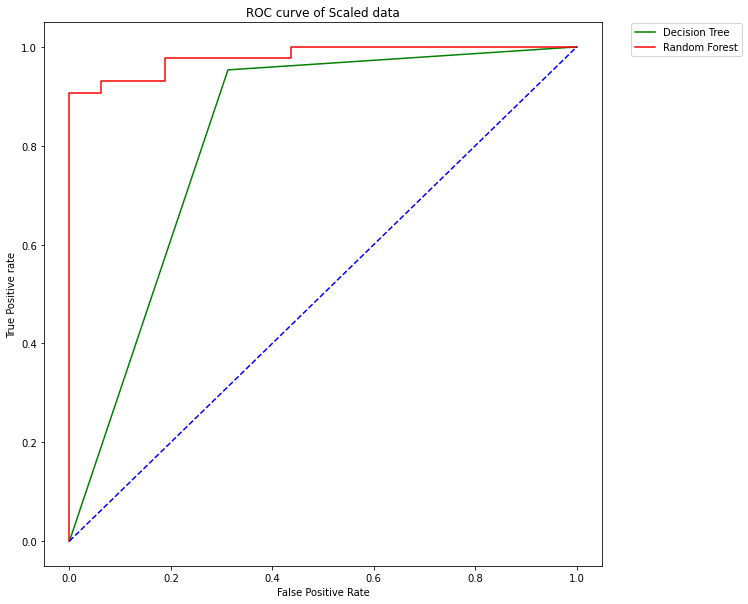

In [100]:
DT_pp=DT_s.predict_proba(scaledX_test)
RF_pp=RF_s.predict_proba(scaledX_test)

fpr_dt, tpr_dt, thresh_dt = roc_curve(y_test,DT_pp[:,1] )
fpr_rf,tpr_rf,thresh_rf=roc_curve(y_test,RF_pp[:,1])

plt.figure(figsize=(10,10))

plt.plot(fpr_dt,tpr_dt,linestyle='solid',color='Green', label='Decision Tree')
plt.plot(fpr_rf,tpr_rf,linestyle='solid',color='red',label='Random Forest')
plt.plot([0, 1], [0, 1],'b--')

model_roc_auc_dt = roc_auc_score(y_test, DT_s.predict(scaledX_test) )
model_roc_auc_rf = roc_auc_score(y_test, RF_s.predict(scaledX_test))          

print ("Area under the curve[Decision_Tree]: ", model_roc_auc_dt)
print ("Area under the curve[Random_Forest]: ", model_roc_auc_rf)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.1)
plt.title('ROC curve of Scaled data')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')

- ROC curve is plotted with True Positive Rate(TPR) against the False Positive Rate(FPR) where TPR is on y-axis and FPR is on the x-axis.

- The Green line represents the Decision Tree model and the red line represents Random Forest model. 

- From the above graph, we can see that red line covers majority of the area. The area under the curve is around 88% for Random Forest.

- Whereas, it is around 82% for Decision Tree model.


### IV. Impact of using Gini and entropy criterion in Random Forest Classifier on Scaled data

##### 1) Gini

In [101]:
rf_gini=RandomForestClassifier(criterion='gini')

fit_n_print(rf_gini, scaledX_train, scaledX_test, y1_train, y1_test)

Train score:  1.0
Test score: 0.8983050847457628
Confusion Matrix:
[[13  3]
 [ 3 40]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        16
           1       0.93      0.93      0.93        43

    accuracy                           0.90        59
   macro avg       0.87      0.87      0.87        59
weighted avg       0.90      0.90      0.90        59



##### 2) Entropy


In [102]:
rf_entropy=RandomForestClassifier(criterion='entropy')

fit_n_print(rf_entropy, scaledX_train, scaledX_test, y1_train, y1_test)


Train score:  1.0
Test score: 0.8983050847457628
Confusion Matrix:
[[12  4]
 [ 2 41]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80        16
           1       0.91      0.95      0.93        43

    accuracy                           0.90        59
   macro avg       0.88      0.85      0.87        59
weighted avg       0.90      0.90      0.90        59



- The test accuracy is more when we use Gini criterion.

- Also we can see a drop in  precision, when we switch from Gini to Entropy. 

#### OOB score

In [103]:
rf=RandomForestClassifier(criterion='gini', oob_score=True)

fit_n_print(rf, scaledX_train, scaledX_test, y1_train, y1_test)

Train score:  1.0
Test score: 0.9152542372881356
Confusion Matrix:
[[13  3]
 [ 2 41]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        16
           1       0.93      0.95      0.94        43

    accuracy                           0.92        59
   macro avg       0.90      0.88      0.89        59
weighted avg       0.91      0.92      0.91        59



In [104]:
print(rf.oob_score_)

0.9044117647058824


- OOB score is 0.904

### V. Impact of varying N estimators on accuracy of Random forest

#### 1) Unscaled data

In [109]:
N_estimators = np.arange(1, 100)
Random_Forest_us_N_est_train_scores = np.empty(len(N_estimators))
Random_Forest_us_N_est_test_scores = np.empty(len(N_estimators))

for i, k in enumerate(N_estimators):
    Random_Forest_N_est = RandomForestClassifier(n_estimators=k)
    Random_Forest_N_est.fit(X_train, y_train)
    train_score_rf = Random_Forest_N_est.score(X_train, y_train)
    test_score_rf = Random_Forest_N_est.score(X_test, y_test)
    Random_Forest_us_N_est_train_scores[i]=train_score_rf
    Random_Forest_us_N_est_test_scores[i]=test_score_rf


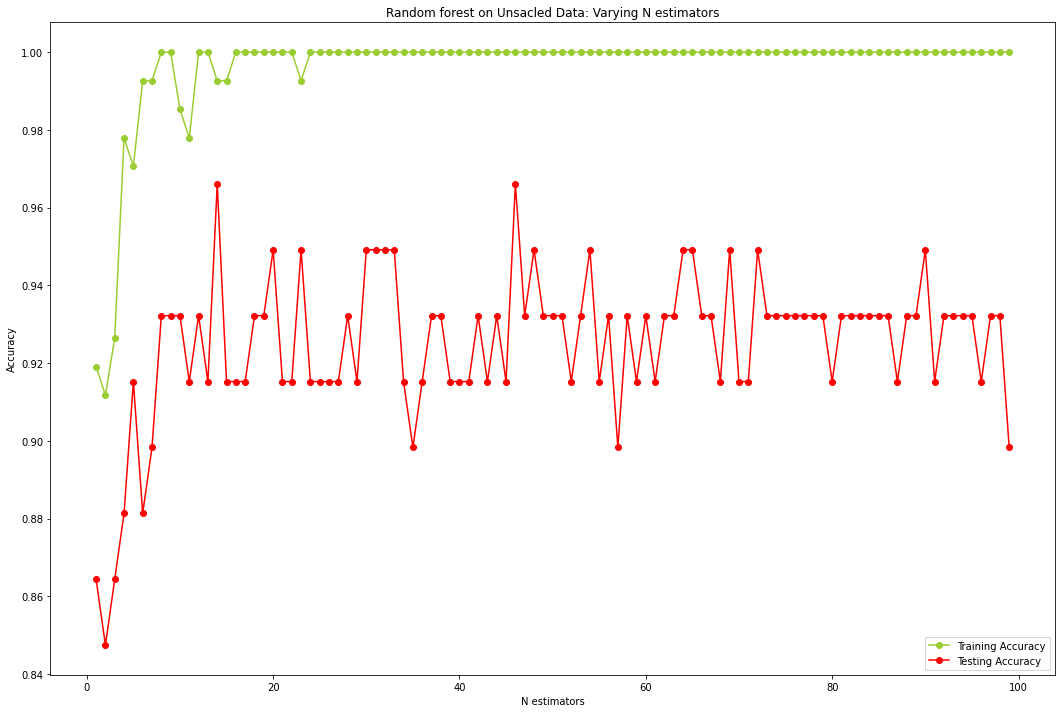

In [110]:
plt.figure(figsize=(18,12))
plt.title('Random forest on Unsacled Data: Varying N estimators')
plt.plot(N_estimators, Random_Forest_us_N_est_train_scores, label = 'Training Accuracy',  marker='o', color='yellowgreen')
plt.plot(N_estimators, Random_Forest_us_N_est_test_scores, label = 'Testing Accuracy', marker='o', color='red')
plt.legend()
plt.xlabel('N estimators')
plt.ylabel('Accuracy')
plt.show()

- Maximum test accuracy is a little above 0.96.

- Maximum train accuracy = 1

- Initially, the training accuracy is just below 0.95. As N estimators increased it gradually increased to 1.

- The test accuracy is initially less than 0.8. But we can see no definite pattern. We can see that the test accuracy is increasing for some values of N estimators and decreasing for some values of N estimators. In between, the test accuracy remained constant for certain ranges of N estimators. 

- The test accuracy is maximum when N estimators is 13.

#### 2) Scaled data

In [111]:
Random_Forest_s_N_est_train_scores = np.empty(len(N_estimators))
Random_Forest_s_N_est_test_scores = np.empty(len(N_estimators))

for i, k in enumerate(N_estimators):
    Random_Forest_N_est = RandomForestClassifier(n_estimators=k)
    Random_Forest_N_est.fit(scaledX_train, y1_train)
    train_score_rf = Random_Forest_N_est.score(scaledX_train, y1_train)
    test_score_rf = Random_Forest_N_est.score(scaledX_test, y1_test)
    Random_Forest_s_N_est_train_scores[i]=train_score_rf
    Random_Forest_s_N_est_test_scores[i]=test_score_rf

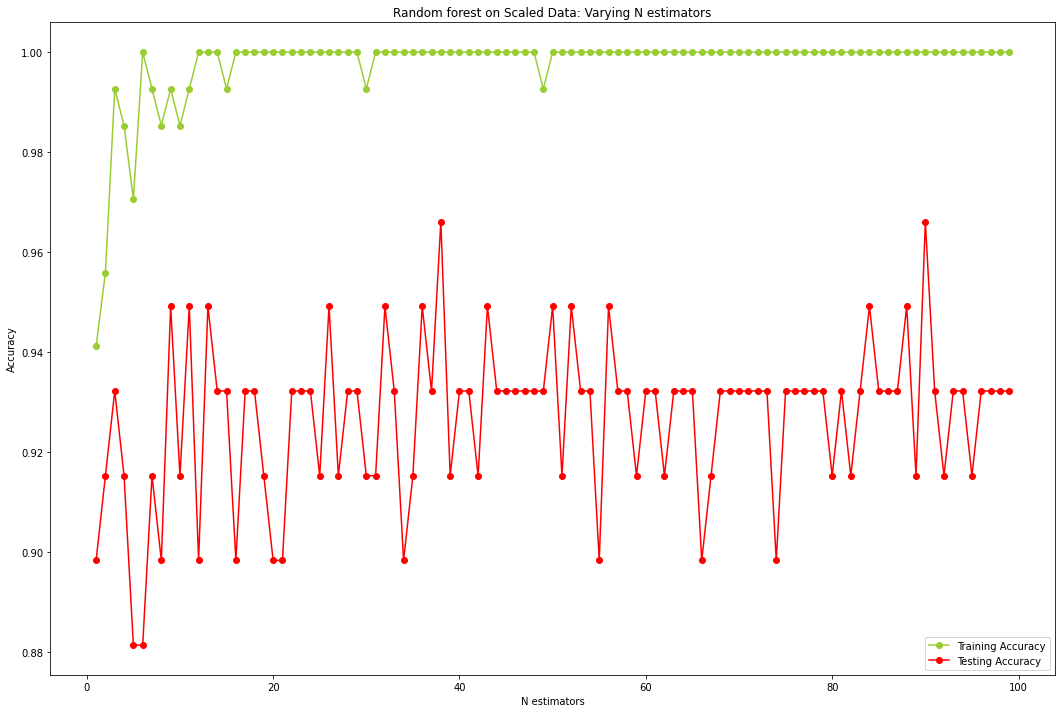

In [112]:
plt.figure(figsize=(18,12))
plt.title('Random forest on Scaled Data: Varying N estimators')
plt.plot(N_estimators, Random_Forest_s_N_est_train_scores, label = 'Training Accuracy',  marker='o', color='yellowgreen')
plt.plot(N_estimators, Random_Forest_s_N_est_test_scores, label = 'Testing Accuracy', marker='o', color='red')
plt.legend()
plt.xlabel('N estimators')
plt.ylabel('Accuracy')
plt.show()

- Maximum test accuracy is a close to  0.97.

- Maximum train accuracy = 1

- Initially, the training accuracy is just below 0.95. As N estimators increased it gradually increased to 1.

- The test accuracy is initially less than 0.825. But we can see no definite pattern. We can see that the test accuracy is increasing for some values of N estimators and decreasing for some values of N estimators. In between, the test accuracy remained constant for certain ranges of N estimators. 

- The test accuracy is maximum for N estimators equals 38.

## Handling imbalance data

- The data is highly imbalanced. We can use various techniques to handle the imbalanced data. 

- Here, I am planning to upsample minority class. It is a process in which the observations are randomly duplicated from the minority class.

- In our case, the minority class is the people who are healthy,that is, status=0.



In [113]:
from  sklearn.utils import resample
DF_PD=DF[DF['status']==1]
DF_Healthy=DF[DF['status']==0]
DF_Upsample_Healthy=resample(DF_Healthy,replace=True,random_state=151,n_samples=147)
DF_Balanced=pd.concat([DF_PD,DF_Upsample_Healthy])

In [114]:
DF_Balanced.status.value_counts()


1    147
0    147
Name: status, dtype: int64

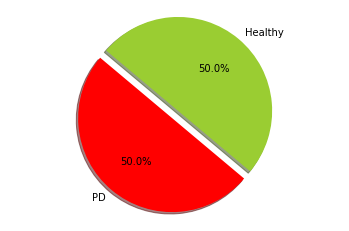

In [115]:
labels ='PD',  'Healthy'
data= DF_Balanced['status'].value_counts()
colors = ['red', 'yellowgreen']
explode = (0.1, 0) 
plt.pie(data, explode=explode, labels=labels, colors=colors,autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')
plt.show()

In [116]:
DF_Balanced.drop('name', axis=1, inplace=True)

In [ ]:
## Data preperation for imbalanced data

In [117]:
y_imbalanced=DF_Final['status']
X_imbalanced= DF_Final.drop('status', axis=1)

In [ ]:
## Data preperation for balanced data

In [118]:
y_balanced=DF_Balanced['status']
X_balanced= DF_Balanced.drop('status', axis=1)

In [ ]:
## Train test split for imbalanced, unscaled data

In [119]:
X_imbalanced_unscaled_train, X_imbalanced_unscaled_test, y_imbalanced_unscaled_train, y_imbalanced_unscaled_test = train_test_split(X_imbalanced, y_imbalanced, test_size=0.3, random_state=10)

In [ ]:
## Train test split for Balanced, unscaled data

In [120]:

X_balanced_unscaled_train, X_balanced_unscaled_test, y_balanced_unscaled_train, y_balanced_unscaled_test = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=10)

In [ ]:
## Train test split for Imbalanced, Scaled data

In [121]:
sc=StandardScaler()

X_imbalanced_train, X_imbalanced_test, y_imbalanced_train, y_imbalanced_test = train_test_split(X_imbalanced, y_imbalanced, test_size=0.30, random_state=10)

scaledX_imbalanced_train = sc.fit_transform(X_imbalanced_train)
scaledX_imbalanced_test = sc.transform(X_imbalanced_test)

In [ ]:
## Train test split for Balanced, scaled data

In [122]:
X_balanced_train, X_balanced_test, y_balanced_train, y_balanced_test = train_test_split(X_balanced, y_balanced, test_size=0.30, random_state=10)

scaledX_balanced_train = sc.fit_transform(X_balanced_train)
scaledX_balanced_test = sc.transform(X_balanced_test)

In [123]:
Decision_Tree = DecisionTreeClassifier()
Random_Forest = RandomForestClassifier()

In [178]:
Accuracy_score_upsampling_DT=[]
Accuracy_score_upsampling_RF=[]

### VI. Unscaled Imbalanced data vs Unscaled balanced data 


##### 1) Unscaled Imbalanced data

In [179]:
## Decision Tree

In [180]:
fit_n_print(Decision_Tree, X_imbalanced_unscaled_train, X_imbalanced_unscaled_test, y_imbalanced_unscaled_train, y_imbalanced_unscaled_test)

test_score_unscaled_imbalanced_DT = Decision_Tree.score(X_imbalanced_unscaled_test, y_imbalanced_unscaled_test)
Accuracy_score_upsampling_DT.append(test_score_unscaled_imbalanced_DT)

Train score:  1.0
Test score: 0.8813559322033898
Confusion Matrix:
[[11  5]
 [ 2 41]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.69      0.76        16
           1       0.89      0.95      0.92        43

    accuracy                           0.88        59
   macro avg       0.87      0.82      0.84        59
weighted avg       0.88      0.88      0.88        59



In [181]:
## Random Forest

In [182]:
fit_n_print(Random_Forest, X_imbalanced_unscaled_train, X_imbalanced_unscaled_test, y_imbalanced_unscaled_train, y_imbalanced_unscaled_test)

test_score_unscaled_imbalanced_RF = Random_Forest.score(X_imbalanced_unscaled_test, y_imbalanced_unscaled_test)
Accuracy_score_upsampling_RF.append(test_score_unscaled_imbalanced_RF)

Train score:  1.0
Test score: 0.9322033898305084
Confusion Matrix:
[[13  3]
 [ 1 42]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87        16
           1       0.93      0.98      0.95        43

    accuracy                           0.93        59
   macro avg       0.93      0.89      0.91        59
weighted avg       0.93      0.93      0.93        59



##### 2) Unscaled balanced data

In [183]:
## Decision Tree

In [184]:
fit_n_print(Decision_Tree, X_balanced_unscaled_train, X_balanced_unscaled_test, y_balanced_unscaled_train, y_balanced_unscaled_test)

test_score_unscaled_balanced_DT = Decision_Tree.score(X_balanced_unscaled_test, y_balanced_unscaled_test)
Accuracy_score_upsampling_DT.append(test_score_unscaled_balanced_DT)

Train score:  1.0
Test score: 0.9775280898876404
Confusion Matrix:
[[52  0]
 [ 2 35]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        52
           1       1.00      0.95      0.97        37

    accuracy                           0.98        89
   macro avg       0.98      0.97      0.98        89
weighted avg       0.98      0.98      0.98        89



In [185]:
## Random Forest

In [186]:
fit_n_print(Random_Forest, X_balanced_unscaled_train, X_balanced_unscaled_test, y_balanced_unscaled_train, y_balanced_unscaled_test)

test_score_unscaled_balanced_RF = Decision_Tree.score(X_balanced_unscaled_test, y_balanced_unscaled_test)
Accuracy_score_upsampling_RF.append(test_score_unscaled_balanced_RF)

Train score:  1.0
Test score: 0.9887640449438202
Confusion Matrix:
[[52  0]
 [ 1 36]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        52
           1       1.00      0.97      0.99        37

    accuracy                           0.99        89
   macro avg       0.99      0.99      0.99        89
weighted avg       0.99      0.99      0.99        89



- In this case, we can see that the false positives are zero for both the models.

---



### VII. Scaled Imbalanced data vs Scaled balanced data 


##### 1) Scaled Imbalanced data

In [187]:
## Decision Tree

In [188]:
fit_n_print(Decision_Tree, scaledX_imbalanced_train, scaledX_imbalanced_test, y_imbalanced_train, y_imbalanced_test)

test_score_scaled_imbalanced_DT = Decision_Tree.score(scaledX_imbalanced_test, y_imbalanced_test)
Accuracy_score_upsampling_DT.append(test_score_scaled_imbalanced_DT)

Train score:  1.0
Test score: 0.8813559322033898
Confusion Matrix:
[[12  4]
 [ 3 40]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        16
           1       0.91      0.93      0.92        43

    accuracy                           0.88        59
   macro avg       0.85      0.84      0.85        59
weighted avg       0.88      0.88      0.88        59



In [189]:
## Random Forest

In [190]:
fit_n_print(Random_Forest, scaledX_imbalanced_train, scaledX_imbalanced_test, y_imbalanced_train, y_imbalanced_test)

test_score_scaled_imbalanced_RF = Random_Forest.score(scaledX_imbalanced_test, y_imbalanced_test)
Accuracy_score_upsampling_RF.append(test_score_scaled_imbalanced_RF)

Train score:  1.0
Test score: 0.9322033898305084
Confusion Matrix:
[[13  3]
 [ 1 42]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87        16
           1       0.93      0.98      0.95        43

    accuracy                           0.93        59
   macro avg       0.93      0.89      0.91        59
weighted avg       0.93      0.93      0.93        59



##### 2) Scaled Balanced data

In [191]:
## Decision Tree

In [192]:
fit_n_print(Decision_Tree, scaledX_balanced_train, scaledX_balanced_test, y_balanced_train, y_balanced_test)

test_score_scaled_balanced_DT = Decision_Tree.score(scaledX_balanced_test, y_balanced_test)
Accuracy_score_upsampling_DT.append(test_score_scaled_balanced_DT)

Train score:  1.0
Test score: 0.9775280898876404
Confusion Matrix:
[[52  0]
 [ 2 35]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        52
           1       1.00      0.95      0.97        37

    accuracy                           0.98        89
   macro avg       0.98      0.97      0.98        89
weighted avg       0.98      0.98      0.98        89



In [193]:
## Random Forest

In [194]:
fit_n_print(Random_Forest, scaledX_balanced_train, scaledX_balanced_test, y_balanced_train, y_balanced_test)

test_score_scaled_balanced_RF = Random_Forest.score(scaledX_balanced_test, y_balanced_test)
Accuracy_score_upsampling_RF.append(test_score_scaled_balanced_RF)

Train score:  1.0
Test score: 0.9887640449438202
Confusion Matrix:
[[52  0]
 [ 1 36]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        52
           1       1.00      0.97      0.99        37

    accuracy                           0.99        89
   macro avg       0.99      0.99      0.99        89
weighted avg       0.99      0.99      0.99        89



- In this case, we can see that the false positives are zero for both the 
models.


- The precision and recall is also pretty good for both the models.





### VIII. Comparing the scaled, unscaled, balanced and imbalanced models


In [195]:
model_list= ["Unscaled Imbalance data", "Unscaled Balanced data"," Scaled Imbalanced data", " Scaled Balanced data"]

##### 1) Decision Tree

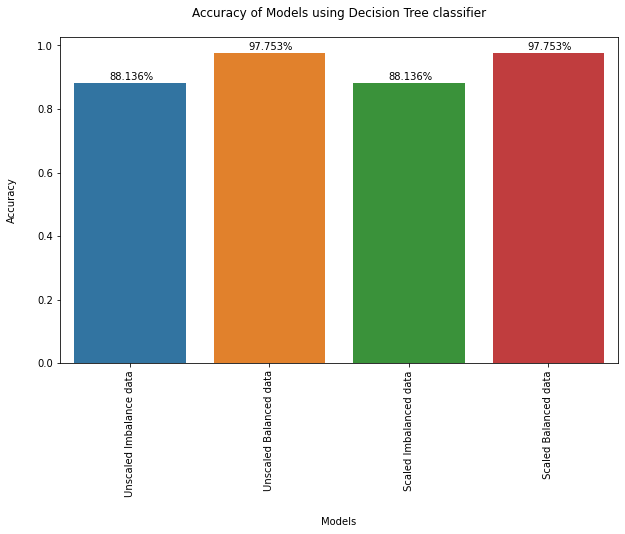

In [196]:
fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(model_list,Accuracy_score_upsampling_DT)
ax.set_title("Accuracy of Models using Decision Tree classifier",pad=20)
ax.set_xlabel("Models",labelpad=20)
ax.set_ylabel("Accuracy",labelpad=20)
plt.xticks(rotation=90)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax.annotate('{:.3%}'.format(height), (x+0.25, y + height + 0.01))

- While using decision tree classifier, we can see that the unscaled balanced data and scaled balanced data have the same test accuracy of 0.98.

- Test accuracy: Scaled Balanced Data = Unscaled Balanced Data > Scaled Imbalanced data = Unscaled Imbalance Data



##### 2) Random Forest

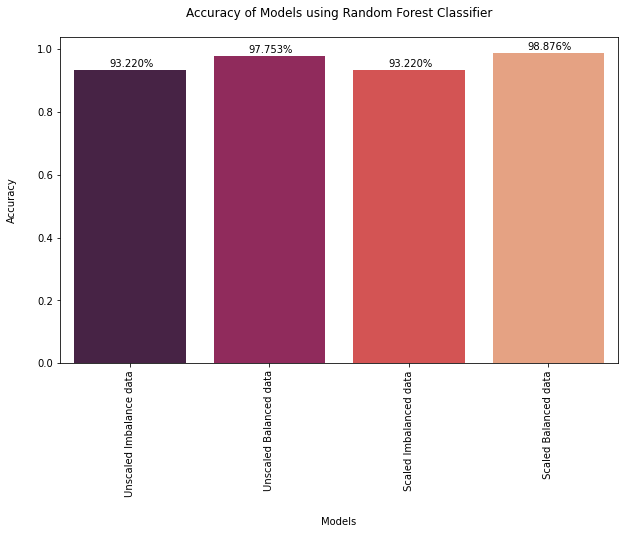

In [197]:
fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(model_list,Accuracy_score_upsampling_RF,palette="rocket")
ax.set_title("Accuracy of Models using Random Forest Classifier",pad=20)
ax.set_xlabel("Models",labelpad=20)
ax.set_ylabel("Accuracy",labelpad=20)
plt.xticks(rotation=90)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax.annotate('{:.3%}'.format(height), (x+0.25, y + height + 0.01))

-  We can see that for scaled balanced data, the test accuracy is maximum, close to 0.988.

- Test accuracy: Scaled Balanced Data > Unscaled Balanced Data  > Scaled Imbalanced data = Unscaled Imbalance Data

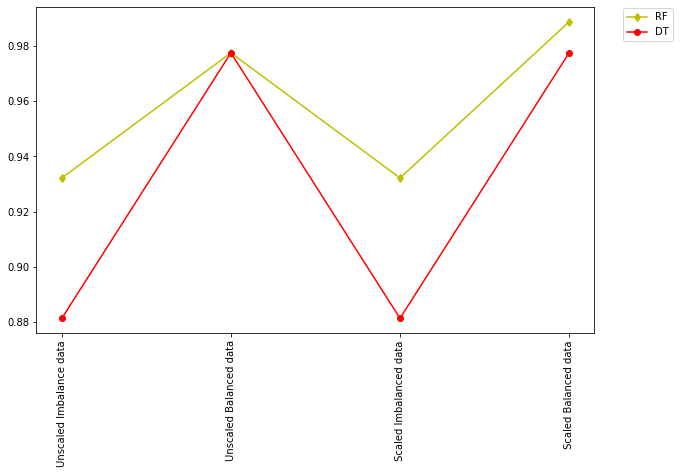

In [198]:
fig,ax=plt.subplots(figsize=(10,6))

plt.plot(model_list,Accuracy_score_upsampling_RF,'y-d', label='RF')
plt.plot(model_list,Accuracy_score_upsampling_DT,'r-o', label='DT')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.1)
plt.xticks(rotation=90)
plt.show()

- Of all the models, we see that the test accuracy is maximum (close to 0.99) when the data is scaled and balanced.

- Random Forest model on Scaled Balanced Data has the highest test accuarcy of 0.9887.

**Representation of a** **Decision** **Tree**

In [199]:
y_1=DF_Final['status']
X_1= DF_Final.drop('status', axis=1)

In [200]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.30, random_state=10)


In [201]:
dt_model = DecisionTreeClassifier(criterion = 'entropy' , min_samples_split=2 )
dt_model.fit(X_train_1, y_train_1)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='entropy',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

In [202]:
from IPython.display import Image  
#import pydotplus as pydot
from sklearn import tree
from os import system

train_char_label = ['1', '2', '3']
PD_Tree_File = open('PD_tree.dot','w')
dot_data = tree.export_graphviz(dt_model, out_file=PD_Tree_File, feature_names = list(X_test_1), class_names = list(train_char_label))

PD_Tree_File.close()

print (pd.DataFrame(dt_model.feature_importances_, columns = ["Imp"], index = X_test_1.columns))

                      Imp
MDVP_Fo_Hz       0.078002
MDVP_Fhi_Hz      0.000000
MDVP_Flo_Hz      0.143281
MDVP_Jitter_pct  0.000000
MDVP_Jitter_Abs  0.047131
MDVP_RAP         0.000000
MDVP_PPQ         0.000000
Jitter_DDP       0.000000
MDVP_Shimmer     0.000000
MDVP_Shimmer_dB  0.000000
Shimmer_APQ3     0.109841
Shimmer_APQ5     0.000000
MDVP_APQ         0.117714
Shimmer_DDA      0.080699
NHR              0.025735
HNR              0.122984
RPDE             0.000000
DFA              0.000000
spread1          0.000000
spread2          0.000000
D2               0.000000
PPE              0.274612


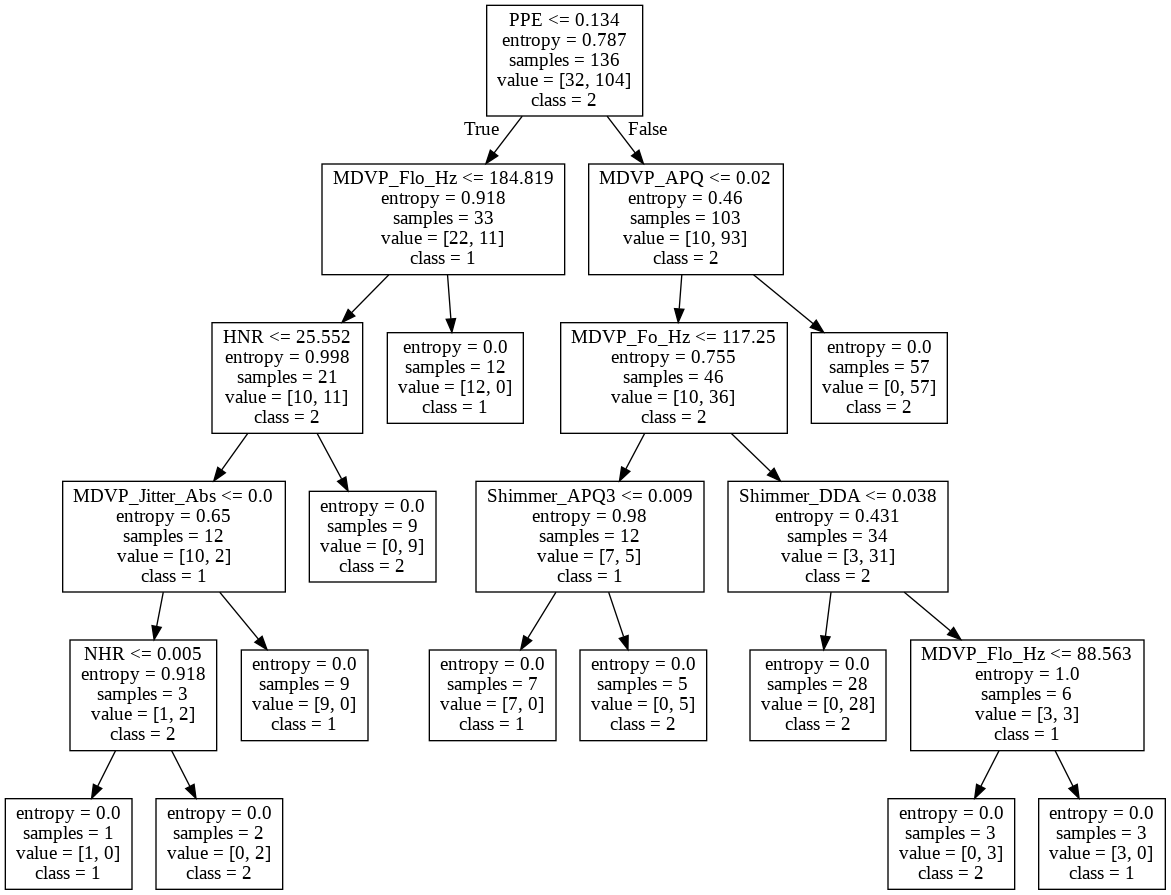

In [203]:
system("dot -Tpng PD_tree.dot -o PD_tree.png")
Image("PD_tree.png")  

- From the above figure, we can see how the splitting is taking place at each step.

**MODEL** **COMPARISION**

In [204]:
models = []
models.append(('Random Forest', RandomForestClassifier()))
models.append(('Decision Tree', DecisionTreeClassifier()))
models.append(('Ada boost', AdaBoostClassifier()))
models.append(('Bagging', BaggingClassifier()))
models.append(('Gradient Boosting', GradientBoostingClassifier()))

# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
	kfold = model_selection.KFold(n_splits=49, random_state=1234)
	cv_results = model_selection.cross_val_score(model, X_1, y_1, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
	print(msg)


Random Forest: 0.870748 (0.268880)
Decision Tree: 0.782313 (0.298720)
Ada boost: 0.850340 (0.258078)
Bagging: 0.862245 (0.247751)
Gradient Boosting: 0.869048 (0.227752)


- Out of all the models, we can see that Random Forest has more accuracy.





**Stacking** **classifier**

In [206]:

dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
bg = BaggingClassifier()
gb = GradientBoostingClassifier()
ab = AdaBoostClassifier()



from sklearn.ensemble import StackingClassifier
estimators = [('dt', dt), ('rf', rf), ('bg', bg), ('gb', gb), ('ab', ab)]
clf = StackingClassifier(estimators = estimators, final_estimator = rf)


fit_n_print(clf, X_train_1, X_test_1, y_train_1, y_test_1)

Train score:  1.0
Test score: 0.9491525423728814
Confusion Matrix:
[[14  2]
 [ 1 42]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        16
           1       0.95      0.98      0.97        43

    accuracy                           0.95        59
   macro avg       0.94      0.93      0.93        59
weighted avg       0.95      0.95      0.95        59



- For stacking classifier, the test accuracy is 0.949




**REMOVING** **FEW** **COLUMNS** **AND** **BUILDING** **MODEL**



In [207]:
y_f=DF_Final['status']
X_f= DF_Final.drop(['MDVP_RAP','Jitter_DDP','Shimmer_APQ3','Shimmer_DDA','status'], axis=1)

In [208]:
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(X_f, y_f, test_size=0.3, random_state=10)

In [209]:
DT = DecisionTreeClassifier(criterion="entropy")
RF = RandomForestClassifier()

In [215]:
fit_n_print(DT , X_f_train, X_f_test, y_f_train, y_f_test)

Train score:  1.0
Test score: 0.9322033898305084
Confusion Matrix:
[[15  1]
 [ 3 40]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        16
           1       0.98      0.93      0.95        43

    accuracy                           0.93        59
   macro avg       0.90      0.93      0.92        59
weighted avg       0.94      0.93      0.93        59



In [216]:
fit_n_print(RF , X_f_train, X_f_test, y_f_train, y_f_test)

Train score:  1.0
Test score: 0.9491525423728814
Confusion Matrix:
[[14  2]
 [ 1 42]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        16
           1       0.95      0.98      0.97        43

    accuracy                           0.95        59
   macro avg       0.94      0.93      0.93        59
weighted avg       0.95      0.95      0.95        59



Comparing model build on unscaled data with this...

- We can see that even though four columns are removed, the test accuracy is the same.

**CONCLUSION**

- When compared with Decision Tree, we can see that the Random Forest models performed better.

- A false positive in this scenario means that the results say you have Parkinson's Disease , but you actually are don't have it and you are healthy. A false negative in this scenario meand that the results say you don’t have Parkinson's Disease, but you actually do havie it.

- A false positive might be causing the person to undergo unneccesary treatment.

- In medical cases, we generally have have less tolerance for false negatives because the person is affected with a disease. But as the results showed he is healthy, the treatment is ignored in this case.

- Ideally, we should be trying to keep both false positives and false negatives minimum as both lead to unneccesary complications.

- For most of the models abvoe, we see that false positives and false negatives are both greater than 0.

- Only when the data is balanced, we can see that the false positives is 0.

- Out of all the models, Random Forest model built on Scaled Balanced Data gave the highest test accuracy(0.9887)
